> **AI-generated.** An AI assistant drafted this page, and no maintainer has reviewed it yet. Please report errors on the issue tracker.

# Tutorial 3: Updating forecasts as data arrive

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/tutorials/03_updating.ipynb)

[Tutorial 2](02_forecasting.ipynb) forecast the moose population after 1988 from a model fit to all the counts.
A forecaster works forward in time instead: each year brings a new count, and the forecast for the next year should use it.
In this tutorial we stand in 1980, fit the model to the counts of 1967 to 1980, and then, for each year from 1981 to 1988, forecast that year's count, observe it, and update the model.
Comparing each forecast with the count that followed tests the forecasts as a forecaster would.

By the end of this tutorial you will have:

1. represented the posterior as particles, each holding the parameters and the current population;
2. forecast one year ahead by moving each particle forward;
3. updated the particles with a new count by Bayes' rule;
4. run the forecast and the update for every year with `iterate` and `with_resampling`;
5. checked how often the forecast intervals held the counts.

The tutorial takes about 25 minutes, and it ends with three exercises.

In [1]:
# On Google Colab, install ProbPipe and download the data; elsewhere this cell does nothing.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import urllib.request

    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/"
        "docs/tutorials/data/moose.csv",
        "data/moose.csv",
    )

In [2]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Beta,
    HalfNormal,
    LogNormal,
    Normal,
    Poisson,
    Weights,
    condition_on,
    conditional_distribution,
    function,
    iterate,
    mean,
    quantile,
    sample,
    with_resampling,
    workflow_run,
)

# TensorFlow Probability warns that JAX runs in 32-bit precision, which these models use.
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype float64")

## 1. The model, fit to 1967 to 1980

This cell repeats tutorial 1's model with process noise and fits it to the first 14 counts, the ones a forecaster in 1980 has.

In [3]:
data = pd.read_csv("data/moose.csv")
years = data["year"].to_numpy()
counts = jnp.asarray(data["count"], dtype=jnp.float32)
FIRST = 14  # the counts of 1967 to 1980
print("years fit:", years[0], "to", years[FIRST - 1])
print("years forecast:", years[FIRST], "to", years[-1])


def trajectory(r, K, n0, shocks):
    """The population in each year after the year of n0, given each year's shock to the growth."""

    def step(N, shock):
        N_next = N * jnp.exp(r * (1.0 - N / K) + shock)
        return N_next, N_next

    _, N = jax.lax.scan(step, jnp.asarray(n0, dtype=jnp.float32), shocks)
    return N


prior = (
    LogNormal("K", jnp.log(350.0), 0.4)
    * LogNormal("r", jnp.log(0.4), 0.4)
    * Beta("phi", 2.0, 2.0)
    * HalfNormal("sigma", 0.2)
    * Normal("shocks", jnp.zeros(FIRST), 1.0)
)


def ricker_counts(K, r, phi, sigma, shocks, n0=50.0):
    return Poisson("y", phi * trajectory(r, K, n0, sigma * shocks))


likelihood = conditional_distribution("counts", ricker_counts, given_spec=prior.event_spec.components)
with workflow_run(seed=1):
    posterior_1980 = condition_on(likelihood * prior, {"y": counts[:FIRST]})
print("number of posterior draws:", posterior_1980.num_atoms)

years fit: 1967 to 1980
years forecast: 1981 to 1988


number of posterior draws: 4000


## 2. Particles

A forecast for 1981 needs the population of 1980 as well as the parameters.
The population of 1980 is a function of the parameters and the shocks, so we apply that function to the posterior, as tutorial 2 did.
The function returns a record, so its result is a distribution over records, with one per posterior draw.
Each record is a **particle**: a set of parameters together with the population that they imply for 1980.

In [4]:
@function
def state_1980(K, r, phi, sigma, shocks):
    population = trajectory(r, K, 50.0, sigma * shocks)
    return {"K": K, "r": r, "phi": phi, "sigma": sigma, "N": population[-1]}


DRAWS = posterior_1980.num_atoms
with workflow_run(seed=2):
    particles = state_1980.with_options(n_broadcast_samples=DRAWS)(
        posterior_1980["K"],
        posterior_1980["r"],
        posterior_1980["phi"],
        posterior_1980["sigma"],
        posterior_1980["shocks"],
    )
print("fields of a particle:", list(particles.event_spec.components))
print("number of particles:", particles.num_atoms)
print("mean population in 1980:", round(float(mean(particles["N"]))))

fields of a particle: ['K', 'N', 'phi', 'r', 'sigma']
number of particles: 4000
mean population in 1980: 327


The particles are an `EmpiricalDistribution`, which is a distribution on finitely many points called its **atoms**, each with a probability called its **weight**.
Here every particle has weight 1/4000.

## 3. Forecasting one year

A forecast moves each particle forward one year: the Ricker step, with a new shock drawn from its prior.
The parameters stay as they are.

In [5]:
@function
def grow(K, r, phi, sigma, N, shock):
    N_next = N * jnp.exp(r * (1.0 - N / K) + sigma * shock)
    return {"K": K, "r": r, "phi": phi, "sigma": sigma, "N": N_next}


shock = Normal("shock", 0.0, 1.0)


def forecast(particles):
    """The particles moved forward one year, each with a new shock."""
    return grow.with_options(n_broadcast_samples=particles.num_atoms)(
        particles["K"], particles["r"], particles["phi"], particles["sigma"], particles["N"], shock
    )

The forecast count follows from the forecast particles through the observation model, $y \sim \text{Poisson}(\phi N)$.
As in tutorial 1, composing that conditional distribution with a distribution of its inputs gives the joint distribution, whose draws of `y` are forecast counts.

In [6]:
observe = conditional_distribution(
    "count",
    lambda phi, N: Poisson("y", phi * N),
    given_spec={"phi": particles.event_spec.components["phi"], "N": particles.event_spec.components["N"]},
)


def count_interval(particles, level=0.9):
    """The central interval of the forecast count with probability *level*."""
    draws = np.asarray(sample(observe * particles, sample_shape=(4000,))["y"].values)
    return np.percentile(draws, [50 * (1 - level), 50 * (1 + level)])


with workflow_run(seed=3):
    particles_1981 = forecast(particles)
    low, high = count_interval(particles_1981)
print(f"forecast count for 1981: 90% interval ({low:.0f}, {high:.0f})")
print("observed count for 1981:", int(counts[FIRST]))

forecast count for 1981: 90% interval (136, 233)
observed count for 1981: 198


## 4. Updating with the new count

Bayes' rule updates a distribution on finitely many points by multiplying each point's probability by the likelihood of the data at that point and renormalizing.
For the particles, the likelihood of the 1981 count at a particle is the Poisson probability of that count with mean $\phi N$.
`observe * particles` is the joint distribution of the particles and the count, so conditioning it on the count with `condition_on` applies Bayes' rule.
For a prior on finitely many points the result is exact, and ProbPipe selects the exact method `empirical_reweighting`, which returns the same particles with their new weights.

In [7]:
def update(particles, count):
    """The particles conditioned on *count* by Bayes' rule."""
    return condition_on(observe * particles, {"y": count})


print("method:", condition_on.check(observe * particles_1981, {"y": counts[FIRST]}).selected.method_name)


def effective_number(particles):
    """The number of equally weighted particles that the weighted particles are worth."""
    return float(Weights(weights=particles.weights).effective_sample_size)


updated_1981 = update(particles_1981, counts[FIRST])
print("effective number of particles before the update:", round(effective_number(particles_1981)))
print("effective number of particles after the update:", round(effective_number(updated_1981)))
print("mean population in 1981 before the update:", round(float(mean(particles_1981["N"]))))
print("mean population in 1981 after the update:", round(float(mean(updated_1981["N"]))))

method: bayes/empirical_reweighting


effective number of particles before the update: 4000
effective number of particles after the update: 2225
mean population in 1981 before the update: 339
mean population in 1981 after the update: 355


The update moves the population toward the value the count suggests, and it concentrates the weight on the particles that agree with the count.
Each year's update concentrates it further, until a few particles hold all the weight.
**Resampling** prevents that: it draws a new set of particles from the weighted ones, so a heavy particle appears several times and a light one disappears, and then gives every particle the same weight.
`with_resampling(step, ess_threshold=0.5)` resamples whenever the effective number falls below half the number of particles.

## 5. Every year from 1981 to 1988

One step of the forecaster's year is a forecast and then an update.
`iterate(step, initial, inputs)` applies `step` to the particles and each count in turn, and returns the particles after each year, starting with 1980's.

In [8]:
def step(particles, count):
    return update(forecast(particles), count)


with workflow_run(seed=4):
    filtered = iterate(with_resampling(step, ess_threshold=0.5), particles, list(counts[FIRST:]))
print("number of years held:", filtered.batch_shape[0])

number of years held: 9


`filtered[t]` is the distribution of the particles after the update of year $1980 + t$.
The population they hold tracks the counts as they arrive:

In [9]:
filtered_years = years[FIRST - 1 :]
levels = jnp.array([0.05, 0.5, 0.95])
bands = np.array(
    [np.asarray(quantile(filtered[t]["N"], levels).values) for t in range(len(filtered_years))]
)
for year, (low, median, high) in zip(filtered_years, bands):
    print(f"{year}: median population {median:.0f}, 90% interval ({low:.0f}, {high:.0f})")

1980: median population 320, 90% interval (238, 442)
1981: median population 347, 90% interval (263, 475)
1982: median population 456, 90% interval (350, 596)
1983: median population 443, 90% interval (357, 601)
1984: median population 429, 90% interval (344, 582)
1985: median population 387, 90% interval (306, 523)
1986: median population 481, 90% interval (394, 655)
1987: median population 444, 90% interval (365, 611)
1988: median population 463, 90% interval (382, 638)


## 6. How good were the forecasts?

The forecast of each year's count comes from the particles of the year before, which have seen every count up to then and none after.
A forecast interval of 90% should hold about 90% of the counts.

counts inside their 90% forecast interval: 6 of 8


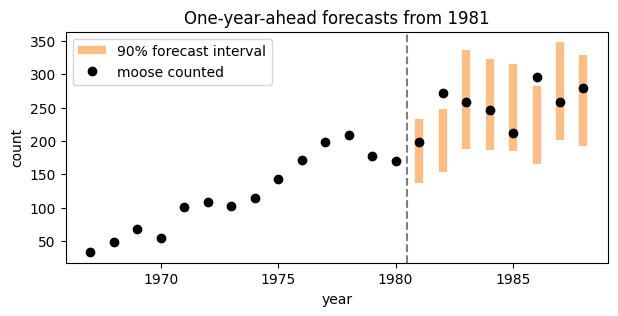

In [10]:
intervals = []
with workflow_run(seed=5):
    for t in range(len(filtered_years) - 1):
        intervals.append(count_interval(forecast(filtered[t])))
intervals = np.array(intervals)
observed = np.asarray(counts[FIRST:])
inside = (observed >= intervals[:, 0]) & (observed <= intervals[:, 1])
print("counts inside their 90% forecast interval:", int(inside.sum()), "of", len(observed))

forecast_years = years[FIRST:]
fig, ax = plt.subplots(figsize=(7, 3))
ax.vlines(forecast_years, intervals[:, 0], intervals[:, 1], color="tab:orange", lw=6, alpha=0.5, label="90% forecast interval")
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.axvline(years[FIRST - 1] + 0.5, color="gray", ls="--")
ax.set(xlabel="year", ylabel="count", title="One-year-ahead forecasts from 1981")
ax.legend(loc="upper left")
plt.show()

With eight forecasts, a coverage between six and eight of eight agrees with the nominal 90%.

## 7. The particles of 1988 and a fit to all the counts

After the update of 1988 the particles have seen every count, as the posterior of tutorial 1 did.
If the updates are accurate, the two agree.

In [11]:
full_prior = (
    LogNormal("K", jnp.log(350.0), 0.4)
    * LogNormal("r", jnp.log(0.4), 0.4)
    * Beta("phi", 2.0, 2.0)
    * HalfNormal("sigma", 0.2)
    * Normal("shocks", jnp.zeros(counts.shape[0]), 1.0)
)
full_likelihood = conditional_distribution(
    "counts", ricker_counts, given_spec=full_prior.event_spec.components
)
with workflow_run(seed=6):
    posterior_1988 = condition_on(full_likelihood * full_prior, {"y": counts})

final = filtered[len(filtered_years) - 1]
for name in ["K", "r", "phi", "sigma"]:
    print(
        f"{name}: mean {float(mean(final[name])):.3f} from the particles,"
        f" {float(mean(posterior_1988[name])):.3f} from the fit to all the counts"
    )

K: mean 443.043 from the particles, 442.226 from the fit to all the counts
r: mean 0.280 from the particles, 0.282 from the fit to all the counts
phi: mean 0.588 from the particles, 0.590 from the fit to all the counts
sigma: mean 0.123 from the particles, 0.124 from the fit to all the counts


The means agree closely.
The particles' parameters are never redrawn, only reweighted and resampled, so over many more years they would collapse onto a few values; a longer series adds a step that moves the particles, such as a few MCMC steps after each resampling.

## 8. Exercises

Each exercise is followed by a solution, which Colab shows collapsed.

**Exercise 1.** Print the effective number of particles after each update, before any resampling, by applying `step` without `with_resampling`.
In which year does it fall below half the number of particles?

In [12]:
# @title Solution
with workflow_run(seed=7):
    unresampled = iterate(step, particles, list(counts[FIRST:]))
for t, year in enumerate(filtered_years[1:], start=1):
    print(f"{year}: effective number of particles {effective_number(unresampled[t]):.0f}")

1981: effective number of particles 2269
1982: effective number of particles 120
1983: effective number of particles 59
1984: effective number of particles 34
1985: effective number of particles 11
1986: effective number of particles 1
1987: effective number of particles 6
1988: effective number of particles 3


**Exercise 2.** Forecast two years ahead instead of one: from the particles of each year, forecast the count of the year after next, and count how many of those intervals hold their counts.

In [13]:
# @title Solution
two_year = []
with workflow_run(seed=8):
    for t in range(len(filtered_years) - 2):
        two_year.append(count_interval(forecast(forecast(filtered[t]))))
two_year = np.array(two_year)
later = np.asarray(counts[FIRST + 1 :])
held = (later >= two_year[:, 0]) & (later <= two_year[:, 1])
print("counts inside their two-year 90% forecast interval:", int(held.sum()), "of", len(later))
print("mean width of the one-year intervals:", round(float(np.mean(intervals[:, 1] - intervals[:, 0]))))
print("mean width of the two-year intervals:", round(float(np.mean(two_year[:, 1] - two_year[:, 0]))))

counts inside their two-year 90% forecast interval: 6 of 7
mean width of the one-year intervals: 126
mean width of the two-year intervals: 149


**Exercise 3.** The forecasts above use 90% intervals.
Compute the 50% intervals with `count_interval(..., level=0.5)` and count how many of the eight counts they hold.
How many would you expect?

In [14]:
# @title Solution
with workflow_run(seed=9):
    halves = np.array(
        [count_interval(forecast(filtered[t]), level=0.5) for t in range(len(filtered_years) - 1)]
    )
held = (observed >= halves[:, 0]) & (observed <= halves[:, 1])
print("counts inside their 50% forecast interval:", int(held.sum()), "of", len(observed))
print("expected number:", 0.5 * len(observed))

counts inside their 50% forecast interval: 5 of 8
expected number: 4.0


## Summary

- Particles represent a posterior as weighted points, each holding the parameters and the current state.
- A forecast moves each particle forward with a new shock, and an update conditions the particles on the new count with `condition_on`, which reweights them exactly by Bayes' rule.
- `iterate` runs the forecast and the update for each year, and `with_resampling` resamples when the weights concentrate.
- The one-year-ahead forecast intervals test the model as a forecaster uses it, and the particles of 1988 agree with a fit to all the counts.

## References

- Doucet, A., de Freitas, N., and Gordon, N. (2001). An introduction to sequential Monte Carlo methods. In *Sequential Monte Carlo Methods in Practice*, Springer.
- Dietze, M. C. (2017). *Ecological Forecasting*. Princeton University Press. It describes particle filters for ecological forecasts.